## Présentation du jeu de données KKBox

### Contexte métier

KKBox est un service de streaming musical par abonnement, comparable à Spotify ou Deezer. Les utilisateurs souscrivent un plan (le plus souvent de **30 jours**) qu'ils peuvent renouveler manuellement ou automatiquement. Ils peuvent aussi **annuler activement** leur abonnement à tout moment.

L'objectif de cette compétition Kaggle est de prédire si un utilisateur **résiliera** (*churn*) après l'expiration de son abonnement — c'est-à-dire s'il ne souscrira pas un nouvel abonnement dans les **30 jours** suivant la date d'expiration.

### La définition du churn est subtile

> *« Subscription cancellation does not imply the user has churned. »*

Le champ `is_cancel` dans la table des transactions indique qu'un utilisateur a **activement annulé** son abonnement. Mais cela ne signifie **pas** qu'il a résilié : un utilisateur peut annuler puis se réabonner dans les 30 jours (par exemple pour changer de plan). Le **vrai critère de churn** est l'absence de toute nouvelle transaction valide dans les 30 jours suivant l'expiration.

C'est pourquoi `is_cancel` est utilisé comme **feature prédictive** dans ce notebook (et non comme proxy direct du label). L'EDA (§5.6) vérifie d'ailleurs que ce signal est légitime et ne constitue pas une fuite de données.

### Structure temporelle des données

La compétition a été actualisée le 6 novembre 2017. Après cette mise à jour, les données s'organisent ainsi :

| Ensemble | Utilisateurs concernés | Période de prédiction |
|----------|----------------------|----------------------|
| **Train** (v1 + v2) | Abonnements expirant en **février** et **mars** 2017 | Churn en ~mars et ~avril 2017 |
| **Test** (v2) | Abonnements expirant en **mars** 2017 | Churn en ~avril 2017 |

Les fichiers `v2` ne remplacent pas les fichiers `v1` — ils les **complètent** en étendant la couverture temporelle. Ce pipeline fusionne donc systématiquement v1 + v2 pour maximiser les données d'entraînement.

### Les 5 tables et leur rôle

| Table | Contenu | Volume | Utilisée dans |
|-------|---------|--------|---------------|
| `train` / `train_v2` | Label de churn par utilisateur (`msno`, `is_churn`) | ~2 M lignes | Labels d'entraînement |
| `sample_submission_v2` | Identifiants du jeu de test (à prédire) | ~900 K lignes | Soumission |
| `members_v3` | Profil utilisateur : ville, âge, genre, canal d'inscription. **Note** : la colonne `bd` (âge) contient des valeurs aberrantes de −7 000 à 2 015, nettoyées en §3.1 | ~6 M lignes | Features démographiques |
| `transactions` / `transactions_v2` | Historique complet des transactions (paiements, renouvellements, annulations) jusqu'au 31/03/2017 | ~22 M lignes | Features transactionnelles (§4.1) |
| `user_logs` / `user_logs_v2` | Logs d'écoute quotidiens (secondes écoutées, chansons par tranche de lecture) jusqu'au 31/03/2017 | **~400 M lignes / ~30 Go** | Features d'écoute (§4.2) |

### Comment la nature des données influence les choix du pipeline

1. **Volume** — Les 30 Go de `user_logs` rendent Pandas inutilisable en direct. DuckDB traite ces données en streaming, sans les charger intégralement en mémoire (§0, §4.2).

2. **Abonnements de 30 jours** — La majorité des plans durent 30 jours, ce qui signifie que beaucoup d'utilisateurs se réabonnent chaque mois. La **dernière transaction** d'un utilisateur (snapshot, §4.1) est donc un indicateur puissant de son état actuel.

3. **`is_cancel` ≠ churn** — L'annulation est un comportement, pas un résultat. Le pipeline l'utilise comme feature (pas comme label) et valide son pouvoir prédictif en EDA (§5.6).

4. **Âges aberrants** — La colonne `bd` contient des valeurs impossibles (ex. −7 000, 2 015). Le nettoyage (§3.1) remplace par `NULL` toute valeur en dehors de l'intervalle [1, 100]. LightGBM gère les `NULL` nativement.

5. **Date de référence = 1er avril 2017** — L'ancienneté de l'abonnement (`membership_duration_days`, §3.1) est calculée par rapport à cette date, qui correspond au début de la période de prédiction du jeu de test.

6. **`expiration_date` supprimée** — Le fichier `members_v3.csv` retire la colonne `expiration_date` qui était un snapshot non fiable. Ce pipeline utilise `members_v3` et n'utilise jamais cette colonne.

7. **Déduplication conservatrice** — Certains utilisateurs apparaissent dans les fichiers v1 et v2 de `train`. La déduplication (§3.3) garde le cas `is_churn = 1` en priorité (`ORDER BY is_churn DESC`), pour ne pas sous-estimer le churn.

---

# KKBox Churn Prediction — Pipeline DuckDB
**Audit → Nettoyage → Feature Engineering → LightGBM → Soumission**

---

### Pourquoi DuckDB ?

DuckDB est un moteur SQL **analytique embarqué** : il s'installe avec un simple `pip install duckdb` et tourne directement dans le processus Python, sans serveur ni configuration externe. Son moteur d'exécution est **vectorisé et colonnaire** — il traite les données par lots optimisés pour le processeur et déborde automatiquement sur le disque quand la RAM est dépassée.

**Avantages clés pour ce projet :**

- **Zéro infrastructure** — pas de serveur externe, pas de cluster, pas de configuration réseau.
- **Lecture Parquet native** — DuckDB ne lit que les colonnes utilisées par la requête (*projection pushdown*) et saute les blocs de lignes qui ne satisfont pas les filtres (*predicate pushdown*).
- **Débordement automatique sur disque** — la table `user_logs` (~30 Go) n'est jamais chargée intégralement en mémoire ; DuckDB gère le spill sur un répertoire temporaire.
- **SQL standard** — les requêtes sont du SQL classique, directement lisible et débugable.

### Architecture du pipeline
```
Fichiers CSV  ──► DuckDB (conversion Parquet, une seule fois)  ──► Parquet sur disque
              ──► DuckDB SQL (audit + nettoyage + features)    ──► DataFrames Pandas
              ──► LightGBM (validation croisée 5-folds)        ──► submission.csv
```

## 0 · Configuration initiale

`con = duckdb.connect()` crée une base de données **en mémoire**, sans processus serveur. DuckDB utilise automatiquement tous les cœurs CPU disponibles et déborde sur le disque quand une requête dépasse la RAM allouée. Aucune définition de schéma n'est nécessaire — les types sont déduits automatiquement depuis les fichiers Parquet.

En passant un chemin de fichier (`duckdb.connect('kkbox.ddb')`), on peut persister les vues entre les sessions. Ici, on utilise les fichiers Parquet comme couche de persistance, ce qui rend le pipeline **reproductible** : il suffit de relancer le notebook pour retrouver le même état.

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gc, warnings
warnings.filterwarnings('ignore')

# !pip install lightgbm duckdb   # uncomment if needed
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    log_loss, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)
import os
os.makedirs("C:/tmp/duckdb", exist_ok=True)


# ── Paths (define FIRST) ──────────────────────────────────────────────
DATA_DIR    = Path("data")          # ← adjust to your local data folder
PARQUET_DIR = DATA_DIR / "parquet"
PARQUET_DIR.mkdir(exist_ok=True)

# ── DuckDB connection ─────────────────────────────────────────────────
con = duckdb.connect()                          # in-memory, Parquet = persistence
con.execute("SET memory_limit = '6.4GB'")
con.execute("SET threads = 4")
con.execute("SET temp_directory = 'C:/tmp/duckdb'")

# Memory limit: set to ~80% of available RAM before DuckDB spills to disk.
con.execute("SET memory_limit = '6.4GB'")
con.execute("SET threads = 4")              # fewer parallel threads = smaller memory peaks
con.execute("SET temp_directory = 'C:/tmp/duckdb'")  # explicit fast-SSD spill path
con = duckdb.connect(str(DATA_DIR / "kkbox.ddb"))  # persists views between sessions


plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"churn": "#e74c3c", "stay": "#2ecc71", "main": "#3498db"}
SEED = 42
np.random.seed(SEED)

print("Setup complete ✓")
print(f"DuckDB version: {duckdb.__version__}")

Setup complete ✓
DuckDB version: 1.4.4


## 1 · Conversion CSV → Parquet (une seule fois)

### Pourquoi convertir en Parquet ?

Un fichier CSV est du texte ligne par ligne — chaque requête doit lire *toutes* les colonnes et convertir le texte en types numériques. Parquet est un format **colonnaire et binaire compressé** :

- **Projection pushdown** — DuckDB ne lit que les colonnes utilisées par la requête. Si on n'a besoin que de `msno`, `total_secs` et `num_100`, seules ces 3 colonnes sur 9 sont lues.
- **Predicate pushdown** — les conditions de filtre (`WHERE`) permettent de sauter des blocs entiers de lignes (appelés *row groups*) sans les lire.
- **Compression** — les données numériques sont compressées 4 à 8× par rapport au CSV.

Pour `user_logs`, cela signifie lire ~6 Go compressés au lieu de 29 Go de CSV brut. C'est le gain de performance le plus important du pipeline.

Cette cellule ne s'exécute qu'**une seule fois** : si les fichiers sentinelles `_SUCCESS` existent déjà, les exécutions suivantes sont instantanées.

In [4]:
def sql_path(p) -> str:
    return str(p).replace("\\", "/")

def csv_to_parquet_single(csv_file: Path, out_file: Path, name: str):
    """
    Convert one CSV to Parquet via DuckDB streaming — no DISTINCT, no memory spike.
    DuckDB reads the CSV in row-group batches and writes directly to Parquet.
    Max memory usage = one row group (~100k rows), not the full file.
    """
    out_file.parent.mkdir(parents=True, exist_ok=True)

    con.execute(f"""
        COPY (
            SELECT * FROM read_csv_auto('{sql_path(csv_file)}', header=True)
        )
        TO '{sql_path(out_file)}'
        (FORMAT PARQUET, COMPRESSION SNAPPY, ROW_GROUP_SIZE 100000)
    """)

    size_gb = out_file.stat().st_size / 1e9
    print(f"  {name}: done → {size_gb:.2f} GB")


def csv_to_parquet(csv_files: list, out_dir: Path, name: str):
    """
    Convert one or more CSVs to Parquet.

    Strategy depends on table size:
      - Small tables (train, members, submissions): one file, DISTINCT dedupliation is fine
      - Large tables (user_logs 30 GB): convert each CSV separately, no DISTINCT.
        Dedup is handled naturally during feature engineering (GROUP BY msno absorbs
        duplicate rows; for train we deduplicate in the cleaning VIEW with QUALIFY).

    This keeps peak memory = one row group regardless of file size.
    """
    sentinel = out_dir / "_SUCCESS"
    if sentinel.exists():
        print(f"  {name}: already converted ✓")
        return

    out_dir.mkdir(parents=True, exist_ok=True)

    if len(csv_files) == 1:
        # Single file — stream directly, no dedup needed
        csv_to_parquet_single(csv_files[0], out_dir / "data.parquet", name)

    else:
        # Multiple files (v1 + v2) — convert each separately to avoid
        # holding both in memory for DISTINCT.
        # Files land as part_0.parquet, part_1.parquet, etc.
        # DuckDB reads them all with read_parquet('dir/*.parquet') later.
        for i, f in enumerate(csv_files):
            out_file = out_dir / f"part_{i}.parquet"
            print(f"  {name} [{i+1}/{len(csv_files)}] converting {f.name}...")
            csv_to_parquet_single(f, out_file, f"  {f.name}")

    sentinel.touch()
    total_gb = sum(f.stat().st_size for f in out_dir.glob("*.parquet")) / 1e9
    print(f"  {name}: complete → {total_gb:.2f} GB total")


print("Converting CSVs to Parquet (first run only)...")

# Small tables — single file each
csv_to_parquet([DATA_DIR / "train.csv", DATA_DIR / "train_v2.csv"],
               PARQUET_DIR / "train",             "train (v1+v2)")
csv_to_parquet([DATA_DIR / "members_v3.csv"],
               PARQUET_DIR / "members",           "members")
csv_to_parquet([DATA_DIR / "transactions.csv", DATA_DIR / "transactions_v2.csv"],
               PARQUET_DIR / "transactions",      "transactions (v1+v2)")
csv_to_parquet([DATA_DIR / "user_logs.csv", DATA_DIR / "user_logs_v2.csv"],
               PARQUET_DIR / "user_logs",         "user_logs (v1+v2)")
csv_to_parquet([DATA_DIR / "sample_submission_v2.csv"],
               PARQUET_DIR / "sample_submission", "sample_submission_v2")

print("\nConversion complete ✓")

Converting CSVs to Parquet (first run only)...
  train (v1+v2) [1/2] converting train.csv...
    train.csv: done → 0.05 GB
  train (v1+v2) [2/2] converting train_v2.csv...
    train_v2.csv: done → 0.04 GB
  train (v1+v2): complete → 0.09 GB total


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  members: done → 0.33 GB
  members: complete → 0.33 GB total
  transactions (v1+v2) [1/2] converting transactions.csv...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    transactions.csv: done → 1.07 GB
  transactions (v1+v2) [2/2] converting transactions_v2.csv...
    transactions_v2.csv: done → 0.07 GB
  transactions (v1+v2): complete → 1.14 GB total
  user_logs (v1+v2) [1/2] converting user_logs.csv...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    user_logs.csv: done → 9.25 GB
  user_logs (v1+v2) [2/2] converting user_logs_v2.csv...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

    user_logs_v2.csv: done → 1.06 GB
  user_logs (v1+v2): complete → 10.31 GB total
  sample_submission_v2: done → 0.04 GB
  sample_submission_v2: complete → 0.04 GB total

Conversion complete ✓


## 2 · Audit des données

### Comment DuckDB audite rapidement de grandes tables

Compter les lignes d'un fichier Parquet (`COUNT(*)`) est quasi-instantané, quelle que soit la taille du fichier : DuckDB lit les **métadonnées du footer** (un résumé stocké à la fin du fichier) sans parcourir les données elles-mêmes.

Pour la détection de valeurs nulles, une seule requête SQL avec `COUNT(*) FILTER (WHERE colonne IS NULL)` pour chaque colonne parcourt le fichier une seule fois et calcule tous les comptages simultanément.

Pour `user_logs` (~30 Go), on utilise un échantillon de 1 % (`USING SAMPLE 1 PERCENT`) — non pas parce que DuckDB ne peut pas gérer le scan complet, mais parce que ~300 000 lignes suffisent largement pour une estimation fiable du taux de valeurs nulles.

In [5]:
def sql_path(p) -> str:
    return str(p).replace("\\", "/")

PATHS = {
    "train":        sql_path(PARQUET_DIR / "train"            / "*.parquet"),
    "members":      sql_path(PARQUET_DIR / "members"          / "*.parquet"),
    "transactions": sql_path(PARQUET_DIR / "transactions"     / "*.parquet"),
    "user_logs":    sql_path(PARQUET_DIR / "user_logs"        / "*.parquet"),
    "sample_sub":   sql_path(PARQUET_DIR / "sample_submission"/ "*.parquet"),
}

# Verify — check parent folder since glob isn't a real path
for name, path in PATHS.items():
    folder = Path(path).parent
    files  = list(folder.glob("*.parquet")) if folder.exists() else []
    total_gb = sum(f.stat().st_size for f in files) / 1e9
    status = f"✓  {len(files)} file(s)  {total_gb:.2f} GB" if files else "✗ not found"
    print(f"  {name:15s}: {status}")

def audit_duckdb(path: str, name: str, sample_pct: float = 100.0):
    """
    Tiered audit using DuckDB:
      - Row count: reads Parquet footer metadata only (instant)
      - Schema:    reads Parquet footer metadata only (instant)
      - Nulls:     single-pass query, optionally on a sample

    sample_pct: percentage of rows to sample for null detection.
                100 = full scan, 1 = 1% sample (for large tables).
    """
    print(f"\n{'='*65}")
    print(f"  {name.upper()}")
    print(f"{'='*65}")

    # Schema — reads Parquet footer only, no row data scanned
    schema = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{path}')").df()
    dtype_summary = schema.groupby("column_type")["column_name"].count().to_dict()
    print(f"  Cols    : {len(schema)}")
    print(f"  Dtypes  : {dtype_summary}")
    print(f"  Columns : {schema['column_name'].tolist()}")

    # Row count — reads row group metadata from Parquet footer (very fast)
    n = con.execute(f"SELECT COUNT(*) FROM read_parquet('{path}')").fetchone()[0]
    print(f"  Rows    : {n:,}")

    # Null detection
    cols = schema["column_name"].tolist()
    if sample_pct < 100.0:
        # USING SAMPLE: DuckDB reservoir sampling — statistically sound
        source = f"(SELECT * FROM read_parquet('{path}') USING SAMPLE {sample_pct} PERCENT)"
        note   = f" (estimated from {sample_pct:.0f}% sample)"
    else:
        source = f"read_parquet('{path}')"
        note   = ""

    # Single SELECT with one COUNT FILTER per column — one scan, all nulls
    null_sql = ", ".join(
        f'COUNT(*) FILTER (WHERE "{c}" IS NULL) AS "{c}"' for c in cols
    )
    null_result = con.execute(f"SELECT {null_sql} FROM {source}").df().iloc[0]
    null_cols   = {c: int(v) for c, v in null_result.items() if v > 0}

    if null_cols:
        print(f"  Nulls{note}:")
        for col_name, cnt in sorted(null_cols.items(), key=lambda x: -x[1]):
            est = int(cnt / (sample_pct / 100)) if sample_pct < 100 else cnt
            pct = est / n * 100
            print(f"    {col_name:35s} ~{est:>10,}  (~{pct:.1f}%)")
    else:
        print(f"  Nulls   : None ✓{note}")

    # Preview — reads first 3 rows only
    print("\n  Preview (3 rows):")
    print(con.execute(f"SELECT * FROM read_parquet('{path}') LIMIT 3").df().to_string(index=False))


audit_duckdb(PATHS["train"],        "train (v1+v2 merged)")
audit_duckdb(PATHS["members"],      "members")
audit_duckdb(PATHS["transactions"], "transactions (v1+v2 merged)")
audit_duckdb(PATHS["user_logs"],    "user_logs (v1+v2 merged)",  sample_pct=1.0)
audit_duckdb(PATHS["sample_sub"],   "sample_submission_v2")

  train          : ✓  2 file(s)  0.09 GB
  members        : ✓  1 file(s)  0.33 GB
  transactions   : ✓  2 file(s)  1.14 GB
  user_logs      : ✓  2 file(s)  10.31 GB
  sample_sub     : ✓  1 file(s)  0.04 GB

  TRAIN (V1+V2 MERGED)
  Cols    : 2
  Dtypes  : {'BIGINT': 1, 'VARCHAR': 1}
  Columns : ['msno', 'is_churn']
  Rows    : 1,963,891
  Nulls   : None ✓

  Preview (3 rows):
                                        msno  is_churn
waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=         1
QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=         1
fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=         1

  MEMBERS
  Cols    : 6
  Dtypes  : {'BIGINT': 4, 'VARCHAR': 2}
  Columns : ['msno', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time']
  Rows    : 6,769,473
  Nulls:
    gender                              ~ 4,429,505  (~65.4%)

  Preview (3 rows):
                                        msno  city  bd gender  registered_via  registration_init_time
Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Nulls   : None ✓ (estimated from 1% sample)

  Preview (3 rows):
                                        msno     date  num_25  num_50  num_75  num_985  num_100  num_unq  total_secs
rxIP2f2aN0rYNp+toI0Obt/N/FYQX8hcO1fTmmy2h34= 20150513       0       0       0        0        1        1     280.335
rxIP2f2aN0rYNp+toI0Obt/N/FYQX8hcO1fTmmy2h34= 20150709       9       1       0        0        7       11    1658.948
yxiEWwE9VR5utpUecLxVdQ5B7NysUPfrNtGINaM2zA8= 20150105       3       3       0        0       68       36   17364.956

  SAMPLE_SUBMISSION_V2
  Cols    : 2
  Dtypes  : {'BIGINT': 1, 'VARCHAR': 1}
  Columns : ['msno', 'is_churn']
  Rows    : 907,471
  Nulls   : None ✓

  Preview (3 rows):
                                        msno  is_churn
4n+fXlyJvfQnTeKXTWT507Ll4JVYGrOC8LHCfwBmPE4=         0
aNmbC1GvFUxQyQUidCVmfbQ0YeCuwkPzEdQ0RwWyeZM=         0
rFC9eSG/tMuzpre6cwcMLZHEYM89xY02qcz7HL4//jc=         0


## 3 · Nettoyage des données

### Les vues SQL (`VIEW`) comme outil de nettoyage

En SQL, une **vue** (`VIEW`) est une requête sauvegardée sous un nom. Elle ne stocke aucune donnée — elle est réévaluée à la volée chaque fois qu'on y fait référence. C'est l'équivalent d'une fonction de transformation : on définit la logique une fois, et on la réutilise partout.

L'avantage est la lisibilité : toute la logique de nettoyage (remplacement de valeurs aberrantes, conversion de types, déduplication) est exprimée en SQL standard, facile à lire et à déboguer. Le plan d'exécution est optimisé par DuckDB automatiquement.

### 3.1 · Nettoyage des membres

Cette cellule crée la vue `members_clean` — une requête SQL sauvegardée qui nettoie la table des membres. Aucune donnée n'est physiquement stockée ; DuckDB exécutera cette requête à la volée chaque fois qu'on référencera `members_clean`.

**Résumé de la requête SQL, étape par étape :**

1. **Déduplication par `ROW_NUMBER()`** — Certains utilisateurs apparaissent plusieurs fois. La clause `ROW_NUMBER() OVER (PARTITION BY msno ORDER BY registration_init_time DESC)` attribue un numéro de rang à chaque ligne *au sein de chaque utilisateur*, trié par date d'inscription (la plus récente en premier). On ne garde que le rang 1 (`WHERE rn = 1`), c'est-à-dire l'enregistrement le plus récent.

2. **Nettoyage de l'âge (`bd`)** — Les âges impossibles (< 1 ou > 100) sont remplacés par `NULL` grâce à un `CASE WHEN`. En SQL, `NULL` signifie « valeur inconnue ». LightGBM, le modèle qu'on utilisera, gère les `NULL` nativement — pas besoin d'imputer une valeur de remplacement.

3. **Encodage du genre** — Les modèles de ML travaillent avec des nombres. La colonne textuelle `gender` est convertie en entier : `'male' → 0`, `'female' → 1`, tout le reste → `NULL`.

4. **Conversion de la date d'inscription** — Les dates brutes sont des entiers au format AAAAMMJJ (ex. `20150101`). La fonction `strptime(CAST(... AS VARCHAR), '%Y%m%d')` convertit d'abord l'entier en chaîne de caractères, puis interprète cette chaîne comme une date. Cela permet ensuite de faire du calcul de dates.

5. **Durée d'abonnement (`membership_duration_days`)** — On calcule le nombre de jours entre la date d'inscription et une date de référence fixe (1er avril 2017) avec `DATE_DIFF('day', date_début, date_fin)`. Plus l'ancienneté est longue, plus l'utilisateur est potentiellement fidèle. Les durées impossibles (négatives ou > 20 ans / 7300 jours) sont exclues par la clause `WHERE ... BETWEEN 0 AND 7300`.

**Résultat :** une vue `members_clean` qui, quand on l'interroge, renvoie une ligne propre par utilisateur avec : `msno`, `city`, `bd` (nettoyé), `gender_enc`, `registered_via`, `registration_date` et `membership_duration_days`.

In [6]:
# QUALIFY is a DuckDB / modern SQL clause that filters AFTER window functions.
# It's cleaner than wrapping the whole query in a subquery with WHERE rn = 1.
con.execute(f"""
    CREATE OR REPLACE VIEW members_clean AS
    SELECT
        msno,
        city,
        registered_via,

        -- Age: replace impossible values with NULL.
        -- LightGBM routes NULLs to the best-fit split child automatically.
        CASE WHEN bd < 1 OR bd > 100 THEN NULL ELSE bd END AS bd,

        -- Gender: encode male=0, female=1, unknown=NULL
        CASE WHEN gender = 'male'   THEN 0
             WHEN gender = 'female' THEN 1
             ELSE NULL END::INTEGER AS gender_enc,

        -- Registration date: YYYYMMDD integer → DATE
        -- strptime parses the string form of the integer using the format mask.
        strptime(CAST(registration_init_time AS VARCHAR), '%Y%m%d')::DATE
            AS registration_date,

        -- Membership duration: days from registration to end of observation window.
        -- More predictive than the raw date — longer members are more loyal.
        DATE_DIFF(
            'day',
            strptime(CAST(registration_init_time AS VARCHAR), '%Y%m%d')::DATE,
            DATE '2017-04-01'
        ) AS membership_duration_days

    FROM (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY msno ORDER BY registration_init_time DESC) AS rn
        FROM read_parquet('{PATHS["members"]}')
    )
    WHERE rn = 1
      -- Drop impossible durations: negative (future registration) or > 20 years
      AND DATE_DIFF(
            'day',
            strptime(CAST(registration_init_time AS VARCHAR), '%Y%m%d')::DATE,
            DATE '2017-04-01'
          ) BETWEEN 0 AND 7300
""")

print("members_clean view created ✓")
con.execute("SELECT * FROM members_clean LIMIT 3").df()

members_clean view created ✓


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,msno,city,registered_via,bd,gender_enc,registration_date,membership_duration_days
0,f++23PLmFtHu31N+ruEG1v/+LGjFLiBT2H3qJISSALk=,4,9,29,0,2009-07-10,2822
1,f+21sIgWk1sUfDUPLYimIWIUUIhCBelFwbnJSe8stHE=,1,7,<NA>,<NA>,2015-09-02,577
2,f+2D+j6nZY+W7z2W8xb1RmCgdLoyqt0rhM0e6OOtTwc=,1,4,<NA>,<NA>,2016-03-03,394


### 3.2 · Nettoyage des transactions

Cette cellule crée la vue `transactions_clean`, qui transforme à la volée la table brute des transactions (chaque renouvellement, paiement ou résiliation d'un utilisateur).

**Résumé de la requête SQL :**

1. **Colonnes conservées telles quelles** — `msno` (identifiant utilisateur), `payment_method_id`, `payment_plan_days`, `plan_list_price`, `actual_amount_paid`, `is_auto_renew`, `is_cancel`.

2. **Conversion des dates** — Les colonnes `transaction_date` et `membership_expire_date` sont des entiers AAAAMMJJ dans les données brutes. On les transforme en vraies dates SQL via `strptime(CAST(... AS VARCHAR), '%Y%m%d')::DATE`, ce qui permet par la suite de calculer des écarts en jours (ex. jours avant expiration).

3. **Colonnes calculées (features dérivées)** :
   - `discount` = `plan_list_price − actual_amount_paid` — le montant de la remise en valeur absolue.
   - `is_discounted` = `1` si la remise est positive, `0` sinon — un indicateur binaire oui/non.

   Ces features sont utiles car les abonnés qui bénéficient de remises peuvent avoir un comportement de churn différent des abonnés plein tarif.

**Résultat :** une vue qui, à chaque appel, renvoie toutes les transactions avec des dates propres et deux colonnes de remise supplémentaires. Aucune donnée n'est stockée en mémoire ni sur disque — c'est une définition de requête.

In [7]:
con.execute(f"""
    CREATE OR REPLACE VIEW transactions_clean AS
    SELECT
        msno,
        payment_method_id,
        payment_plan_days,
        plan_list_price,
        actual_amount_paid,
        is_auto_renew,
        is_cancel,

        -- Parse YYYYMMDD integers to proper DATE columns.
        -- CAST to VARCHAR first because strptime expects a string input.
        strptime(CAST(transaction_date       AS VARCHAR), '%Y%m%d')::DATE AS transaction_date,
        strptime(CAST(membership_expire_date AS VARCHAR), '%Y%m%d')::DATE AS membership_expire_date,

        -- Discount features: computed once here, referenced in both
        -- the snapshot (last transaction) and aggregate feature queries below.
        plan_list_price - actual_amount_paid AS discount,
        CASE WHEN plan_list_price - actual_amount_paid > 0 THEN 1 ELSE 0 END AS is_discounted

    FROM read_parquet('{PATHS["transactions"]}')
""")

print("transactions_clean view created ✓")
con.execute("SELECT * FROM transactions_clean LIMIT 3").df()

transactions_clean view created ✓


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,is_cancel,transaction_date,membership_expire_date,discount,is_discounted
0,YyO+tlZtAXYXoZhNr3Vg3+dfVQvrBVGO8j1mfqe4ZHc=,41,30,129,129,1,0,2015-09-30,2015-11-01,0,0
1,AZtu6Wl0gPojrEQYB8Q3vBSmE2wnZ3hi1FbK1rQQ0A4=,41,30,149,149,1,0,2015-09-30,2015-10-31,0,0
2,UkDFI97Qb6+s2LWcijVVv4rMAsORbVDT2wNXF0aVbns=,41,30,129,129,1,0,2015-09-30,2016-04-27,0,0


### 3.3 · Nettoyage des labels d'entraînement

La table `train` contient les étiquettes (labels) : pour chaque utilisateur, `is_churn = 1` s'il a résilié, `0` s'il est resté. Certains utilisateurs y apparaissent en double.

**Résumé de la requête SQL :**

```sql
SELECT msno, is_churn
FROM read_parquet(...)
QUALIFY ROW_NUMBER() OVER (PARTITION BY msno ORDER BY is_churn DESC) = 1
```

- `PARTITION BY msno` — regroupe les lignes par utilisateur.
- `ORDER BY is_churn DESC` — en cas de doublon, la ligne avec `is_churn = 1` (churn) est classée en premier. On conserve le cas le plus « pessimiste » par précaution.
- `QUALIFY` — mot-clé propre à DuckDB (et à quelques autres dialectes SQL modernes) qui filtre **après** l'évaluation de la fonction fenêtre. C'est plus lisible que d'écrire une sous-requête.

**Résultat :** la vue `train_clean` contient exactement une ligne par utilisateur avec deux colonnes : `msno` et `is_churn`.

In [8]:
# QUALIFY = filter after window function evaluation — cleaner than a subquery.
con.execute(f"""
    CREATE OR REPLACE VIEW train_clean AS
    SELECT msno, is_churn
    FROM read_parquet('{PATHS["train"]}')
    QUALIFY ROW_NUMBER() OVER (PARTITION BY msno ORDER BY is_churn DESC) = 1
""")

n_train = con.execute("SELECT COUNT(*) FROM train_clean").fetchone()[0]
print(f"train_clean view created ✓  ({n_train:,} users)")

train_clean view created ✓  (1,082,190 users)


## 4 · Feature Engineering (création de variables prédictives)

### Le pattern de cache Parquet

Certaines agrégations sont coûteuses (notamment sur les 30 Go de logs). Pour éviter de les recalculer à chaque exécution, on écrit le résultat dans un fichier Parquet. Aux exécutions suivantes, on vérifie si le fichier existe et on le lit directement — ce qui prend quelques secondes au lieu de plusieurs minutes.

```
1ère exécution :  Agrégation DuckDB → écriture Parquet     (minutes)
Exécutions suivantes :  read_parquet(...)                   (secondes)
```

### Division sûre avec `NULLIF(dénominateur, 0)`

Toutes les features de type ratio utilisent `NULLIF(x, 0)` au dénominateur. Quand `x = 0`, `NULLIF` renvoie `NULL` au lieu de provoquer une erreur de division par zéro. Le `NULL` se propage dans l'arithmétique et LightGBM le gère nativement en routant ces observations vers la branche de l'arbre qui minimise le mieux la perte.

### 4.1 · Features de transactions

On construit deux tables complémentaires par utilisateur, combinées ensuite en une seule :

**1. Dernière transaction (snapshot)** — La requête utilise `QUALIFY ROW_NUMBER() OVER (PARTITION BY msno ORDER BY transaction_date DESC) = 1` pour isoler la transaction la plus récente de chaque utilisateur. Cela donne des features comme : dernier mode de paiement, dernier montant payé, dernier flag d'annulation, nombre de jours avant expiration, etc. Ces variables capturent l'**état courant** de l'abonnement.

**2. Historique agrégé** — Un `GROUP BY msno` sur l'ensemble des transactions résume le comportement à long terme : nombre total de transactions (`COUNT(*)`), montant total et moyen payé (`SUM`, `AVG`), variabilité des paiements (`STDDEV`), fréquence d'annulation (`AVG(is_cancel)`), diversité des moyens de paiement (`COUNT(DISTINCT payment_method_id)`), etc.

Les deux sous-requêtes sont jointes avec `JOIN ... USING (msno)` et le résultat est écrit en Parquet (pattern de cache décrit ci-dessus), puis enregistré comme vue `txn_features` pour être réutilisé dans la fusion finale.

In [9]:
TXN_PARQUET = str(PARQUET_DIR / "txn_features" / "data.parquet")
TXN_PARQUET_SQL = sql_path(TXN_PARQUET)

if Path(TXN_PARQUET).exists():
    print("Loading cached transaction features...")

else:
    print("Building transaction features...")
    Path(TXN_PARQUET).parent.mkdir(exist_ok=True)

    last_txn_sql = """
        SELECT
            msno,
            payment_method_id           AS last_payment_method,
            payment_plan_days           AS last_plan_days,
            plan_list_price             AS last_list_price,
            actual_amount_paid          AS last_amount_paid,
            is_auto_renew               AS last_auto_renew,
            is_cancel                   AS last_is_cancel,
            discount                    AS last_discount,
            is_discounted               AS last_is_discounted,
            -- Negative days_to_expire = already expired = strong churn signal
            DATE_DIFF('day', transaction_date, membership_expire_date) AS days_to_expire,
            -- NULLIF prevents division by zero, returns NULL instead
            discount / NULLIF(plan_list_price, 0)  AS last_discount_pct
        FROM transactions_clean
        QUALIFY ROW_NUMBER() OVER (PARTITION BY msno ORDER BY transaction_date DESC) = 1
    """

    txn_agg_sql = """
        SELECT
            msno,
            COUNT(*)                                AS txn_count,
            SUM(actual_amount_paid)                 AS total_paid,
            AVG(actual_amount_paid)                 AS avg_paid,
            COALESCE(STDDEV(actual_amount_paid), 0) AS std_paid,  -- NULL for single-row users
            AVG(payment_plan_days)                  AS avg_plan_days,
            AVG(is_auto_renew)                      AS auto_renew_pct,
            AVG(is_cancel)                          AS cancel_pct,
            SUM(is_cancel)                          AS cancel_count,
            COUNT(DISTINCT payment_method_id)       AS n_payment_methods,
            COUNT(DISTINCT payment_plan_days)       AS n_unique_plans,
            MAX(plan_list_price)                    AS max_list_price,
            MIN(plan_list_price)                    AS min_list_price,
            MAX(actual_amount_paid)                 AS max_paid,
            MIN(actual_amount_paid)                 AS min_paid,
            MAX(actual_amount_paid) - MIN(actual_amount_paid) AS price_range
        FROM transactions_clean
        GROUP BY msno
    """

    # Join snapshot + history and write to Parquet in one query
    con.execute(f"""
        COPY (
            SELECT l.*, a.* EXCLUDE (msno)
            FROM ({last_txn_sql}) l
            FULL OUTER JOIN ({txn_agg_sql}) a USING (msno)
        )
        TO '{TXN_PARQUET}' (FORMAT PARQUET, COMPRESSION SNAPPY)
    """)
    print(f"  Saved → {TXN_PARQUET}")


# Register as a DuckDB view for use in the master join
con.execute(f"CREATE OR REPLACE VIEW txn_features AS SELECT * FROM read_parquet('{TXN_PARQUET}')")

n_u = con.execute("SELECT COUNT(*) FROM txn_features").fetchone()[0]
n_c = len(con.execute("SELECT * FROM txn_features LIMIT 1").df().columns)
print(f"✓ Transaction features: {n_u:,} users × {n_c} cols")
con.execute("SELECT * FROM txn_features LIMIT 3").df()

Building transaction features...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Saved → C:\Users\JJAll\Desktop\DU DATA (local, Not Drive)\Machine Learning 2\Projet\parquet\txn_features\data.parquet
✓ Transaction features: 2,426,143 users × 26 cols


,msno,last_payment_method,last_plan_days,last_list_price,last_amount_paid,last_auto_renew,last_is_cancel,last_discount,last_is_discounted,days_to_expire,...,auto_renew_pct,cancel_pct,cancel_count,n_payment_methods,n_unique_plans,max_list_price,min_list_price,max_paid,min_paid,price_range
0,xl3SKLv7qRQXBrfT5YhgB5aJw62+gw5MntcPsxwAIBk=,41,30,149,149,1,1,0,0,0,...,1.00,0.100000,1.0,1,1,149,149,149,149,0
1,J4AlQpq6t3qx2F1DVD9sdn4itkVYC0VCFdR11b9H+xE=,32,180,699,699,0,0,0,0,180,...,0.96,0.040000,1.0,2,3,699,0,699,119,580
2,SBG+XxLLLbnsJ5KTAHfSQJh6FdK0NBlA8vQNqexDOIA=,41,30,149,149,1,1,0,0,1,...,1.00,0.142857,1.0,1,2,149,0,149,149,0


### 4.2 · Features de logs d'écoute

C'est la requête la plus lourde du pipeline : elle agrège ~30 Go de données d'écoute en une seule ligne par utilisateur. DuckDB gère cela en **exécution streaming** — il traite les *row groups* Parquet par lots et déborde sur le disque si la RAM est dépassée. Aucune boucle de chunking manuelle n'est nécessaire.

**Ce que la requête calcule (par utilisateur) :**

- **Volume d'écoute** — nombre de jours actifs (`COUNT`), total / max / min / moyenne / écart-type des secondes écoutées.
- **Décomptes par tranche de lecture** — `num_25` (chansons écoutées à 0-25 %), `num_50`, `num_75`, `num_985`, `num_100` (écoutées jusqu'au bout), `num_unq` (chansons uniques). Sommés et moyennés.
- **Ratios d'engagement** — taux de complétion (`num_100 / total_plays`), taux de skip (`num_25 / total_plays`), ratio de diversité (`num_unq / total_plays`), secondes moyennes par chanson, etc. Tous calculés avec `NULLIF(dénominateur, 0)` pour éviter les divisions par zéro.

La première exécution prend quelques minutes. Le résultat est écrit en Parquet (~30 Mo) et toutes les exécutions suivantes le lisent en moins d'une seconde.

In [10]:
LOG_PARQUET     = str(PARQUET_DIR / "log_features" / "data.parquet")
LOG_PARQUET_SQL = sql_path(LOG_PARQUET)

if Path(LOG_PARQUET).exists():
    print("Loading cached log features...")

else:
    print("Building log features — DuckDB streaming over 30+ GB Parquet...")
    print("(Takes a few minutes on first run — cached forever after)")
    Path(LOG_PARQUET).parent.mkdir(exist_ok=True)

    con.execute(f"""
        COPY (
            SELECT
                msno,

                -- ── Listening volume ─────────────────────────────────────
                COUNT(date)                          AS total_logs,
                SUM(total_secs)                      AS total_secs_sum,
                MAX(total_secs)                      AS total_secs_max,
                MIN(total_secs)                      AS total_secs_min,
                AVG(total_secs)                      AS total_secs_mean,
                -- COALESCE: STDDEV returns NULL for users with only 1 active day
                COALESCE(STDDEV(total_secs), 0.0)    AS total_secs_std,

                -- ── Play-count breakdowns ─────────────────────────────────
                -- num_25 = songs played 0-25% through, num_100 = played to completion
                SUM(num_25)   AS num_25_sum,   SUM(num_50)  AS num_50_sum,
                SUM(num_75)   AS num_75_sum,   SUM(num_985) AS num_985_sum,
                SUM(num_100)  AS num_100_sum,  SUM(num_unq) AS num_unq_sum,
                AVG(num_25)   AS num_25_mean,  AVG(num_100) AS num_100_mean,
                AVG(num_unq)  AS num_unq_mean,
                SUM(num_25 + num_50 + num_75 + num_985 + num_100) AS total_plays,

                -- ── Engagement ratios ─────────────────────────────────────
                -- NULLIF(denominator, 0) returns NULL instead of dividing by zero.
                -- LightGBM routes NULL rows to the best-fit split child automatically.

                -- completion_rate: fraction of songs played to the end
                SUM(num_100) / NULLIF(SUM(num_25+num_50+num_75+num_985+num_100), 0)
                                                     AS completion_rate,
                -- skip_rate: fraction abandoned in the first 25%
                SUM(num_25)  / NULLIF(SUM(num_25+num_50+num_75+num_985+num_100), 0)
                                                     AS skip_rate,
                SUM(num_50)  / NULLIF(SUM(num_25+num_50+num_75+num_985+num_100), 0)
                                                     AS half_listen_rate,
                SUM(num_985) / NULLIF(SUM(num_25+num_50+num_75+num_985+num_100), 0)
                                                     AS near_complete_rate,
                -- diversity_ratio: unique songs / total plays
                SUM(num_unq) / NULLIF(SUM(num_25+num_50+num_75+num_985+num_100), 0)
                                                     AS diversity_ratio,
                SUM(total_secs) / NULLIF(SUM(num_25+num_50+num_75+num_985+num_100), 0)
                                                     AS avg_secs_per_song,
                -- daily_plays: average songs per active day
                SUM(num_25+num_50+num_75+num_985+num_100) / NULLIF(COUNT(date), 0)
                                                     AS daily_plays,

                -- ── Active span ──────────────────────────────────────────
                -- date is stored as YYYYMMDD integer in Parquet (raw from CSV).
                -- Must cast to VARCHAR then parse to DATE before DATE_DIFF.
                -- strptime(CAST(x AS VARCHAR), '%Y%m%d')::DATE is the standard
                -- pattern for YYYYMMDD integers throughout this pipeline.
                DATE_DIFF(
                    'day',
                    strptime(CAST(MIN(date) AS VARCHAR), '%Y%m%d')::DATE,
                    strptime(CAST(MAX(date) AS VARCHAR), '%Y%m%d')::DATE
                ) AS active_days_span

            FROM read_parquet('{PATHS["user_logs"]}')
            GROUP BY msno
        )
        TO '{LOG_PARQUET_SQL}' (FORMAT PARQUET, COMPRESSION SNAPPY)
    """)
    print(f"  Saved → {LOG_PARQUET}")


con.execute(f"CREATE OR REPLACE VIEW log_features AS SELECT * FROM read_parquet('{LOG_PARQUET_SQL}')")

n_u = con.execute("SELECT COUNT(*) FROM log_features").fetchone()[0]
n_c = len(con.execute("SELECT * FROM log_features LIMIT 1").df().columns)
print(f"✓ Log features: {n_u:,} users × {n_c} cols")
con.execute("SELECT * FROM log_features LIMIT 3").df()

Building log features — DuckDB streaming over 30+ GB Parquet...
(Takes a few minutes on first run — cached forever after)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Saved → C:\Users\JJAll\Desktop\DU DATA (local, Not Drive)\Machine Learning 2\Projet\parquet\log_features\data.parquet
✓ Log features: 5,339,422 users × 25 cols


,msno,total_logs,total_secs_sum,total_secs_max,total_secs_min,total_secs_mean,total_secs_std,num_25_sum,num_50_sum,num_75_sum,...,num_unq_mean,total_plays,completion_rate,skip_rate,half_listen_rate,near_complete_rate,diversity_ratio,avg_secs_per_song,daily_plays,active_days_span
0,XaPDtJFT8wUO30ZSdHNPIugp+wFL3j+kbDRVcSbV3GU=,628,4741275.185,43798.701,111.125,7549.801250,6060.620351,3175.0,1224.0,672.0,...,30.921975,23110.0,0.751103,0.137386,0.052964,0.029468,0.840286,205.161194,36.799363,817
1,nKGxvwNackVpAi04nZuEmWUqTYJzIursrtspU4efDqo=,328,1824728.992,24208.255,0.418,5563.198146,4091.172835,5103.0,366.0,270.0,...,35.682927,12568.0,0.521801,0.406031,0.029122,0.021563,0.931254,145.188494,38.317073,379
2,huQc6+mlEN1iLEZEhdv2+gBE7XbqJ3U8oRU+cGrw6OA=,581,2575819.654,32654.710,136.725,4433.424534,3488.030259,815.0,206.0,152.0,...,15.693632,11351.0,0.880275,0.071800,0.018148,0.016386,0.803277,226.924470,19.537005,820


### 4.3 · Fusion → Datasets maîtres

Cette cellule exécute la requête de fusion principale et crée les deux **DataFrames Pandas** centraux du pipeline : `df_train` et `df_test`.

**Comment la requête SQL fonctionne :**

La requête utilise une série de `LEFT JOIN ... USING (msno)` pour combiner quatre sources :
- la table source (`train` ou `sample_submission`) qui fournit la liste des utilisateurs,
- `members_clean` — les données démographiques nettoyées,
- `txn_features` — les features de transactions (snapshot + agrégats),
- `log_features` — les features d'écoute agrégées.

Le `LEFT JOIN` garantit que **chaque utilisateur** de la table source apparaît dans le résultat, même s'il n'a pas de transactions ou de logs (les colonnes correspondantes seront `NULL`).

**Création des DataFrames :**

- **`df_train`** — le résultat de la fusion pour les utilisateurs d'entraînement. Contient toutes les features *plus* la colonne `is_churn` (l'étiquette à prédire). C'est le DataFrame principal sur lequel reposent l'EDA et l'entraînement du modèle.
- **`df_test`** — la même fusion mais pour les utilisateurs du jeu de test (sans colonne `is_churn`). Servira à produire les prédictions finales.

DuckDB retourne les résultats via un **pont Arrow zero-copy** (méthode `.df()`), ce qui est très rapide car les données ne sont pas recopiées entre la mémoire DuckDB et la mémoire Pandas.

Le rapport de couverture (`MERGE COVERAGE REPORT`) vérifie quelle proportion d'utilisateurs a effectivement des données dans chaque table jointe.

In [11]:
MASTER_SQL = """
    SELECT
        t.msno,
        {label_col}
        m.city, m.bd, m.gender_enc, m.registered_via, m.membership_duration_days,

        -- Transaction snapshot
        x.last_payment_method, x.last_plan_days,    x.last_list_price,
        x.last_amount_paid,    x.last_auto_renew,   x.last_is_cancel,
        x.last_discount,       x.last_is_discounted, x.last_discount_pct,
        x.days_to_expire,

        -- Transaction aggregates
        x.txn_count,      x.total_paid,     x.avg_paid,      x.std_paid,
        x.avg_plan_days,  x.auto_renew_pct, x.cancel_pct,    x.cancel_count,
        x.n_payment_methods, x.n_unique_plans,
        x.max_list_price, x.min_list_price,  x.max_paid, x.min_paid, x.price_range,

        -- Log volume
        l.total_logs, l.total_secs_sum, l.total_secs_max, l.total_secs_min,
        l.total_secs_mean, l.total_secs_std,

        -- Log play counts
        l.num_25_sum, l.num_50_sum, l.num_75_sum, l.num_985_sum, l.num_100_sum,
        l.num_unq_sum, l.num_25_mean, l.num_100_mean, l.num_unq_mean, l.total_plays,

        -- Log engagement ratios
        l.completion_rate, l.skip_rate,    l.half_listen_rate,
        l.near_complete_rate, l.diversity_ratio, l.avg_secs_per_song,
        l.daily_plays, l.active_days_span

    FROM {source} t
    LEFT JOIN members_clean  m USING (msno)
    LEFT JOIN txn_features   x USING (msno)
    LEFT JOIN log_features   l USING (msno)
"""

# Train: include is_churn label
df_train = con.execute(
    MASTER_SQL.format(
        label_col="t.is_churn,",
        source=f"read_parquet('{PATHS['train']}')"
    )
).df()

# Test: no label column
df_test = con.execute(
    MASTER_SQL.format(
        label_col="",
        source=f"read_parquet('{PATHS['sample_sub']}')"
    )
).df()

print(f"df_train: {df_train.shape}")
print(f"df_test:  {df_test.shape}")

# Coverage report
print("\nMERGE COVERAGE REPORT")
print("=" * 60)
for group, col in [("members", "city"), ("transactions", "txn_count"), ("user_logs", "total_logs")]:
    tr = df_train[col].notna().mean() * 100
    te = df_test[col].notna().mean()  * 100
    print(f"  {group:15s}  train: {tr:5.1f}%  test: {te:5.1f}%")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

df_train: (1963891, 56)
df_test:  (907471, 55)

MERGE COVERAGE REPORT
  members          train:  88.5%  test:  87.6%
  transactions     train: 100.0%  test: 100.0%
  user_logs        train:  87.9%  test:  86.9%


## 4.3.1 Features : Résumé

### Features déjà présentes dans les CSVs bruts (passthrough ou renommées)

| Feature | Colonne d'origine | Table source |
|---|---|---|
| `city` | `city` | members_v3 |
| `registered_via` | `registered_via` | members_v3 |
| `last_payment_method` | `payment_method_id` | transactions |
| `last_plan_days` | `payment_plan_days` | transactions |
| `last_list_price` | `plan_list_price` | transactions |
| `last_amount_paid` | `actual_amount_paid` | transactions |
| `last_auto_renew` | `is_auto_renew` | transactions |
| `last_is_cancel` | `is_cancel` | transactions |
| `num_25_sum/mean` | `num_25` | user_logs |
| `num_50_sum` | `num_50` | user_logs |
| `num_75_sum` | `num_75` | user_logs |
| `num_985_sum` | `num_985` | user_logs |
| `num_100_sum/mean` | `num_100` | user_logs |
| `num_unq_sum/mean` | `num_unq` | user_logs |

---

### Features construites par le code

#### Nettoyées / transformées (même concept, calcul nécessaire)

| Feature | Transformation |
|---|---|
| `bd` | Valeurs hors [1, 100] remplacées par `NULL` |
| `gender_enc` | Encodage string → entier (`male=0`, `female=1`) |

#### Véritablement engineerées (information nouvelle, absente des données brutes)

| Feature | Formule / logique |
|---|---|
| `membership_duration_days` | `DATE_DIFF(registration_date, 2017-04-01)` |
| `discount` | `plan_list_price − actual_amount_paid` |
| `is_discounted` | `1 si discount > 0 sinon 0` |
| `last_discount` | `discount` à la dernière transaction |
| `last_is_discounted` | `is_discounted` à la dernière transaction |
| `last_discount_pct` | `discount / plan_list_price` à la dernière transaction |
| `days_to_expire` | `DATE_DIFF(transaction_date, membership_expire_date)` |
| `txn_count` | `COUNT(*)` sur toutes les transactions |
| `total_paid` | `SUM(actual_amount_paid)` |
| `avg_paid` | `AVG(actual_amount_paid)` |
| `std_paid` | `STDDEV(actual_amount_paid)` |
| `avg_plan_days` | `AVG(payment_plan_days)` |
| `auto_renew_pct` | `AVG(is_auto_renew)` |
| `cancel_pct` | `AVG(is_cancel)` |
| `cancel_count` | `SUM(is_cancel)` |
| `n_payment_methods` | `COUNT(DISTINCT payment_method_id)` |
| `n_unique_plans` | `COUNT(DISTINCT payment_plan_days)` |
| `max/min_list_price` | `MAX/MIN(plan_list_price)` |
| `max/min_paid` | `MAX/MIN(actual_amount_paid)` |
| `price_range` | `max_paid − min_paid` |
| `total_logs` | `COUNT(date)` — jours actifs |
| `total_secs_sum/max/min/mean/std` | Agrégations de `total_secs` |
| `total_plays` | `SUM(num_25 + num_50 + num_75 + num_985 + num_100)` |
| `daily_plays` | `total_plays / total_logs` |
| `completion_rate` | `num_100_sum / total_plays` |
| `skip_rate` | `num_25_sum / total_plays` |
| `half_listen_rate` | `num_50_sum / total_plays` |
| `near_complete_rate` | `num_985_sum / total_plays` |
| `diversity_ratio` | `num_unq_sum / total_plays` |
| `avg_secs_per_song` | `total_secs_sum / total_plays` |
| `active_days_span` | `DATE_DIFF(MIN(date), MAX(date))` sur l'ensemble des logs |

### 4.4 · Matrice de features

Maintenant que `df_train` contient une ligne par utilisateur avec toutes les features et le label de churn, on sépare les données dans le format attendu par le modèle de machine learning :

- **`X_train`** (DataFrame Pandas) — la **matrice de features** : toutes les colonnes de `df_train` *sauf* l'identifiant utilisateur (`msno`) et le label (`is_churn`). Ce sont les variables explicatives que le modèle utilisera pour apprendre.
- **`y_train`** (Series Pandas) — le **vecteur cible** : uniquement la colonne `is_churn`. C'est ce que le modèle cherche à prédire (0 = resté, 1 = résilié).
- **`X_test`** (DataFrame Pandas) — la matrice de features pour les utilisateurs du jeu de test (pas de label disponible).

La cellule affiche aussi le taux de valeurs manquantes pour chaque feature. Un taux > 30 % est signalé par ⚠️, mais LightGBM gère les `NULL` nativement (il route ces observations vers la meilleure branche de l'arbre), donc aucune imputation manuelle n'est nécessaire.

In [12]:
DROP_COLS    = {"msno", "is_churn"}
feature_cols = [c for c in df_train.columns if c not in DROP_COLS]

X_train = df_train[feature_cols]
y_train = df_train["is_churn"]
X_test  = df_test[feature_cols]

print(f"Training:  {X_train.shape}")
print(f"Test:      {X_test.shape}")
print(f"\nFeatures ({len(feature_cols)}) — null rates:")
for c in feature_cols:
    null_tr = X_train[c].isna().mean() * 100
    null_te = X_test[c].isna().mean()  * 100
    flag = "  ⚠️" if null_tr > 30 else ""
    print(f"  {c:35s}  train {null_tr:5.1f}%   test {null_te:5.1f}%{flag}")

Training:  (1963891, 54)
Test:      (907471, 54)

Features (54) — null rates:
  city                                 train  11.5%   test  12.4%
  bd                                   train  60.5%   test  65.4%  ⚠️
  gender_enc                           train  60.3%   test  64.9%  ⚠️
  registered_via                       train  11.5%   test  12.4%
  membership_duration_days             train  11.5%   test  12.4%
  last_payment_method                  train   0.0%   test   0.0%
  last_plan_days                       train   0.0%   test   0.0%
  last_list_price                      train   0.0%   test   0.0%
  last_amount_paid                     train   0.0%   test   0.0%
  last_auto_renew                      train   0.0%   test   0.0%
  last_is_cancel                       train   0.0%   test   0.0%
  last_discount                        train   0.0%   test   0.0%
  last_is_discounted                   train   0.0%   test   0.0%
  last_discount_pct                    train   0.4%   te

## 5 · Analyse exploratoire (EDA)

L'EDA s'exécute entièrement en Pandas sur les DataFrames `df_train` / `X_train` / `y_train` déjà agrégés. DuckDB a fait le gros du travail en amont ; ici, on visualise les résultats pour comprendre les données avant de modéliser.

### 5.1 · Distribution de la variable cible

Avant de construire un modèle, il est essentiel de comprendre l'**équilibre des classes** — combien d'utilisateurs ont résilié vs. sont restés. Si les classes sont très déséquilibrées (ex. seulement ~7 % de churn), un modèle naïf qui prédit toujours « pas de churn » obtiendrait 93 % de précision — un chiffre élevé mais totalement inutile.

Ce diagramme en barres montre les effectifs et pourcentages exacts de chaque classe pour évaluer le déséquilibre et orienter le choix des métriques d'évaluation (AUC et précision-rappel plutôt que l'accuracy brute).

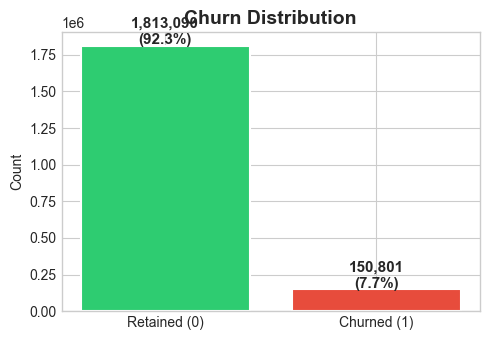

Churn rate: 7.68%  |  Class balance: 12.0:1


In [13]:
n_train = len(df_train)
counts  = y_train.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(["Retained (0)", "Churned (1)"], counts.values,
              color=[COLORS["stay"], COLORS["churn"]], edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + n_train * 0.005,
            f"{v:,}\n({v/n_train:.1%})", ha="center", fontweight="bold", fontsize=11)
ax.set_title("Churn Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout(); plt.show()
print(f"Churn rate: {y_train.mean():.2%}  |  Class balance: {counts[0]/counts[1]:.1f}:1")

### 5.2 · Patterns transactionnels

Ces trois graphiques explorent la relation entre les features transactionnelles et le churn :

1. **Auto-renouvellement** (`last_auto_renew`) — les utilisateurs dont le renouvellement automatique est activé résilient-ils moins souvent ? En général, oui, et de façon marquée.
2. **Flag d'annulation** (`last_is_cancel`) — l'utilisateur a-t-il explicitement annulé lors de sa dernière transaction ? C'est l'un des signaux prédictifs les plus forts.
3. **Durée du plan** (`last_plan_days`) — les churners et non-churners souscrivent-ils à des plans de durées différentes ?

Chaque graphique superpose les deux classes (resté / résilié) pour permettre une comparaison visuelle directe.

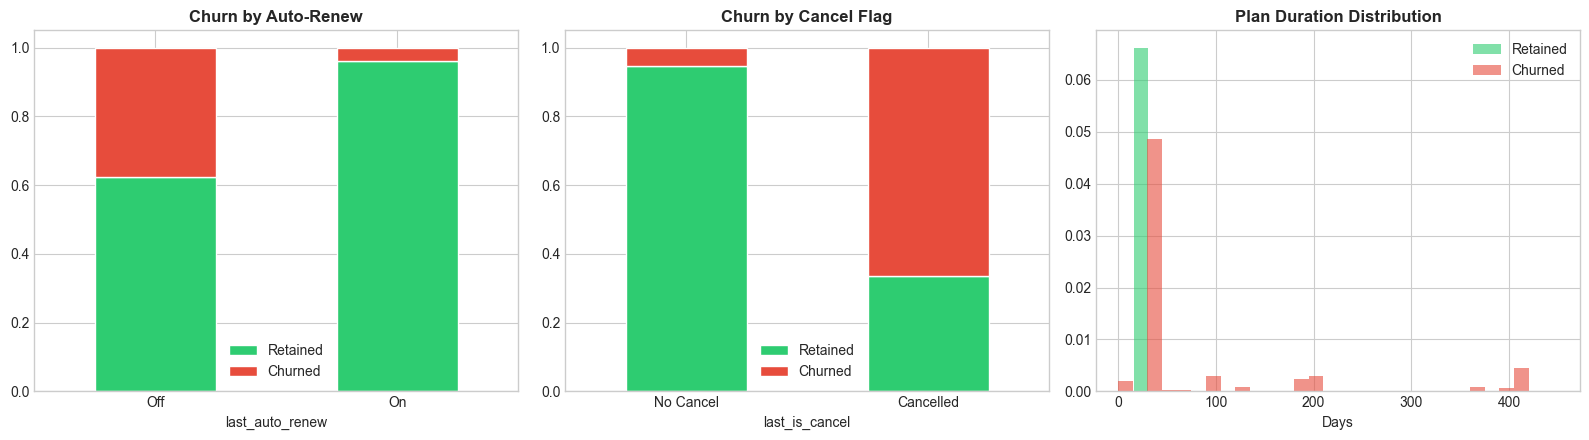

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pd.crosstab(df_train["last_auto_renew"], y_train, normalize="index").plot(
    kind="bar", stacked=True, ax=axes[0], color=[COLORS["stay"], COLORS["churn"]], edgecolor="white")
axes[0].set_title("Churn by Auto-Renew", fontweight="bold")
axes[0].set_xticklabels(["Off", "On"], rotation=0)
axes[0].legend(["Retained", "Churned"])

pd.crosstab(df_train["last_is_cancel"], y_train, normalize="index").plot(
    kind="bar", stacked=True, ax=axes[1], color=[COLORS["stay"], COLORS["churn"]], edgecolor="white")
axes[1].set_title("Churn by Cancel Flag", fontweight="bold")
axes[1].set_xticklabels(["No Cancel", "Cancelled"], rotation=0)
axes[1].legend(["Retained", "Churned"])

for label, color, lbl in [(0, COLORS["stay"], "Retained"), (1, COLORS["churn"], "Churned")]:
    axes[2].hist(df_train[y_train == label]["last_plan_days"].dropna(),
                 bins=30, alpha=0.6, color=color, density=True, label=lbl)
axes[2].set_title("Plan Duration Distribution", fontweight="bold")
axes[2].set_xlabel("Days"); axes[2].legend()
plt.tight_layout(); plt.show()

### 5.3 · Comportement d'écoute

Le comportement d'écoute capture *la quantité* et *la profondeur* de l'engagement des utilisateurs avec le service :

1. **Durée moyenne d'écoute quotidienne** — les churners écoutent-ils moins en moyenne ?
2. **Taux de complétion** (`completion_rate`) — la fraction de chansons écoutées jusqu'à la fin. Un taux faible peut signaler une insatisfaction.
3. **Nombre de jours actifs** (`total_logs`) — combien de jours l'utilisateur a-t-il enregistré une activité ?

Les valeurs sont tronquées au 99e percentile pour éviter que les valeurs extrêmes n'écrasent le graphique. Les histogrammes superposés permettent de voir si les distributions diffèrent entre les deux classes.

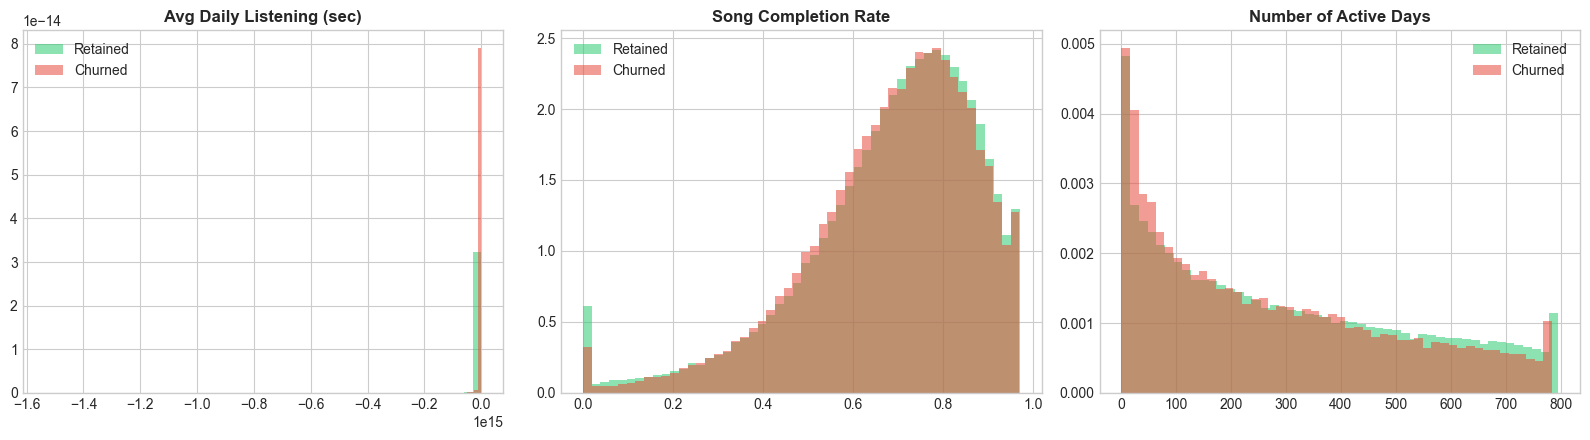

In [15]:
avg_daily = df_train["total_secs_sum"] / df_train["total_logs"].replace(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (series, title) in zip(axes, [
    (avg_daily,                    "Avg Daily Listening (sec)"),
    (df_train["completion_rate"],  "Song Completion Rate"),
    (df_train["total_logs"],       "Number of Active Days"),
]):
    for label, color, lbl in [(0, COLORS["stay"], "Retained"),
                               (1, COLORS["churn"], "Churned")]:
        subset = series[y_train == label].dropna()
        ax.hist(subset.clip(upper=subset.quantile(0.99)),
                bins=50, alpha=0.55, color=color, density=True, label=lbl)
    ax.set_title(title, fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()

### 5.4 · Démographie

Ces graphiques vérifient si les attributs démographiques — âge, genre et canal d'inscription — sont associés au churn. Par exemple, les utilisateurs plus jeunes ou ceux inscrits via un canal particulier pourraient résilier plus fréquemment. Si c'est le cas, le modèle pourra exploiter ces signaux.

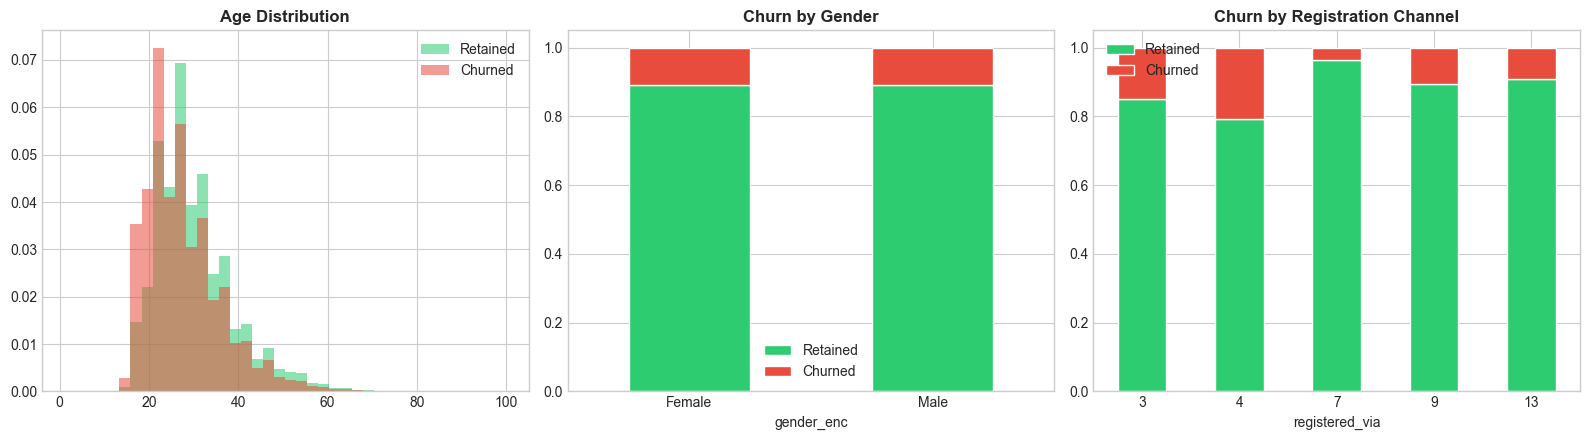

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for label, color, lbl in [(0, COLORS["stay"], "Retained"), (1, COLORS["churn"], "Churned")]:
    axes[0].hist(df_train[y_train == label]["bd"].dropna(),
                 bins=40, alpha=0.55, color=color, density=True, label=lbl)
axes[0].set_title("Age Distribution", fontweight="bold"); axes[0].legend()

pd.crosstab(df_train["gender_enc"].map({0: "Male", 1: "Female"}),
            y_train, normalize="index").plot(
    kind="bar", stacked=True, ax=axes[1], color=[COLORS["stay"], COLORS["churn"]], edgecolor="white")
axes[1].set_title("Churn by Gender", fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(["Retained", "Churned"])

top_reg = df_train["registered_via"].value_counts().head(6).index
pd.crosstab(df_train[df_train["registered_via"].isin(top_reg)]["registered_via"],
            y_train, normalize="index").plot(
    kind="bar", stacked=True, ax=axes[2], color=[COLORS["stay"], COLORS["churn"]], edgecolor="white")
axes[2].set_title("Churn by Registration Channel", fontweight="bold")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(["Retained", "Churned"])
plt.tight_layout(); plt.show()

### 5.5 · Carte de corrélations

La **corrélation** mesure la relation linéaire entre deux variables numériques, sur une échelle de −1 (relation inverse parfaite) à +1 (relation directe parfaite). Une feature fortement corrélée avec le churn sera probablement un bon prédicteur.

Le panneau de gauche classe les features par corrélation avec le label de churn — les valeurs positives (rouge) signifient « quand cette feature augmente, le churn augmente aussi ». Le panneau de droite montre les corrélations *entre features* : des paires très corrélées portent une information redondante, ce qui est utile à savoir lors de l'interprétation du modèle.

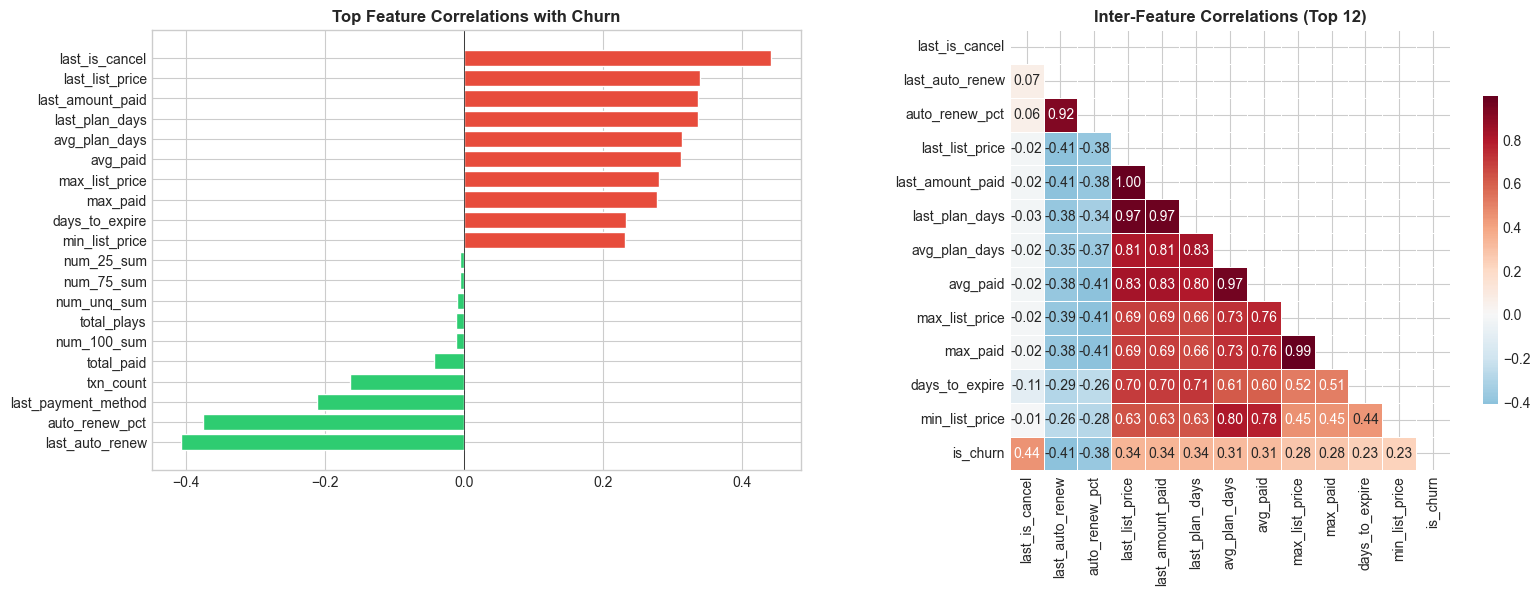

In [17]:
num_cols = [c for c in feature_cols
            if X_train[c].dtype in ["float64","int64","float32","int32"]
            and X_train[c].notna().mean() > 0.5]
tgt_corr = df_train[num_cols].corrwith(y_train).sort_values()
top_corr = pd.concat([tgt_corr.head(10), tgt_corr.tail(10)])
top12    = tgt_corr.abs().sort_values(ascending=False).head(12).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_c = [COLORS["churn"] if v > 0 else COLORS["stay"] for v in top_corr.values]
axes[0].barh(top_corr.index, top_corr.values, color=colors_c, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.5)
axes[0].set_title("Top Feature Correlations with Churn", fontweight="bold")

corr_matrix = df_train[top12 + ["is_churn"]].corr()
sns.heatmap(corr_matrix, mask=np.triu(np.ones_like(corr_matrix, dtype=bool)),
            annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7})
axes[1].set_title("Inter-Feature Correlations (Top 12)", fontweight="bold")
plt.tight_layout(); plt.show()

### 5.6 · Valeurs manquantes et validation du signal `is_cancel`

Ce tableau croisé (`crosstab`) examine la relation entre le flag `last_is_cancel` et le churn réel. Il répond à la question : « parmi les utilisateurs dont la dernière transaction était une annulation, quelle proportion a effectivement résilié ? » Cela permet de valider que le flag d'annulation est un signal comportemental légitime et non une fuite de données (*data leakage*) — c'est-à-dire qu'il a été enregistré *avant* que le résultat de churn ne soit déterminé.

In [18]:
# Pandas — since df_train is already in memory
pd.crosstab(df_train["last_is_cancel"], df_train["is_churn"],
            margins=True, normalize="index")

is_churn,0,1
last_is_cancel,,
0,0.946874,0.053126
1,0.335487,0.664513
All,0.923213,0.076787


Vérification complémentaire : parmi tous les utilisateurs qui *ont* résilié, quelle proportion avait une annulation sur leur transaction la plus récente ? Si la quasi-totalité des churners avait annulé, la feature est fortement prédictive — mais il faut confirmer qu'elle reflète un comportement réel de l'utilisateur et non un artefact du processus d'étiquetage.

In [19]:
# Of all churners, how many had cancel = 1?
df_train[df_train["is_churn"] == 1]["last_is_cancel"].mean()

np.float64(0.33491157220442835)

Ce graphique visualise le pourcentage de valeurs manquantes pour chaque feature du jeu d'entraînement. Les features sont colorées par gravité : rouge si > 30 % de valeurs manquantes, orange si > 10 %, bleu sinon. LightGBM gère les valeurs manquantes en interne (il route les observations `NULL` vers la branche de l'arbre qui minimise le mieux l'erreur), donc l'imputation n'est pas strictement nécessaire — mais connaître le profil de données manquantes reste important pour évaluer la qualité des données.

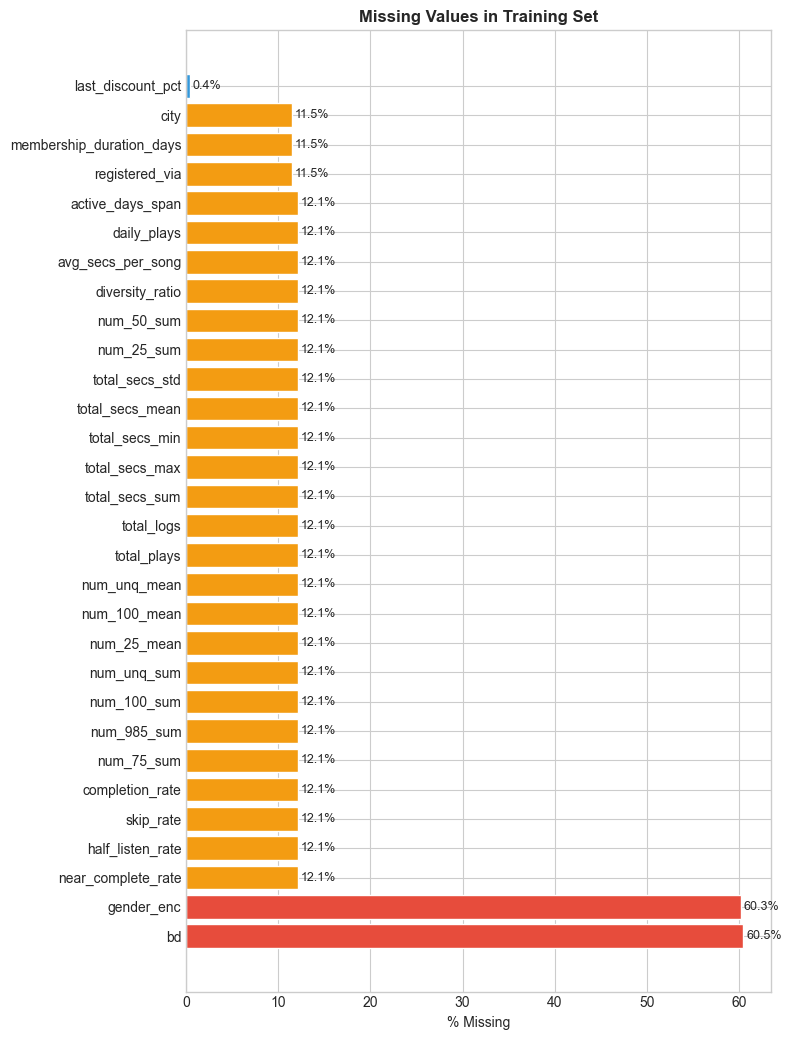

Note: LightGBM handles NaN natively — no imputation needed.


In [20]:
missing_pct = X_train.isnull().mean().sort_values(ascending=False) * 100
has_missing = missing_pct[missing_pct > 0]

if len(has_missing):
    fig, ax = plt.subplots(figsize=(8, max(3, len(has_missing) * 0.35)))
    colors_m = ["#e74c3c" if v > 30 else "#f39c12" if v > 10 else "#3498db"
                for v in has_missing.values]
    ax.barh(has_missing.index, has_missing.values, color=colors_m, edgecolor="white")
    ax.set_xlabel("% Missing")
    ax.set_title("Missing Values in Training Set", fontweight="bold")
    for i, (col, v) in enumerate(has_missing.items()):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
    plt.tight_layout(); plt.show()
    print("Note: LightGBM handles NaN natively — no imputation needed.")
else:
    print("No missing values ✓")

## 6 · Entraînement — LightGBM, validation croisée à 5 folds

### Notes sur les hyperparamètres

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `learning_rate` | 0.05 | Taux bas — on s'appuie sur l'early stopping pour trouver le nombre optimal d'arbres |
| `num_leaves` | 63 | ≈ 2⁶ ; équilibre entre expressivité et sur-apprentissage |
| `max_depth` | 7 | Limite de profondeur comme régularisateur secondaire |
| `min_child_samples` | 50 | Minimum 50 observations par feuille — empêche le sur-découpage |
| `subsample` | 0.8 | Sous-échantillonnage de lignes par arbre |
| `colsample_bytree` | 0.8 | Sous-échantillonnage de features par arbre |
| `n_estimators` | 1500 | Borne supérieure — l'early stopping (patience = 50) trouve l'optimum réel |

`StratifiedKFold` préserve le taux de churn (~7 %) dans chaque fold, ce qui garantit que les prédictions OOF (Out-Of-Fold) sont comparables d'un fold à l'autre et que l'AUC OOF global est une estimation non biaisée de la capacité de généralisation.

In [21]:
params = {
    "objective":         "binary",
    "metric":            "binary_logloss",
    "boosting_type":     "gbdt",
    "learning_rate":     0.05,
    "num_leaves":        63,
    "max_depth":         7,
    "min_child_samples": 50,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "reg_alpha":         0.1,
    "reg_lambda":        1.0,
    "n_estimators":      1500,
    "random_state":      SEED,
    "verbose":           -1,
}

N_FOLDS      = 5
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds    = np.zeros(len(X_train))
test_preds   = np.zeros(len(X_test))
feat_imp     = np.zeros(len(feature_cols))
fold_results = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0),
        ],
    )

    oof_preds[val_idx]  = model.predict_proba(X_val)[:, 1]
    test_preds         += model.predict_proba(X_test)[:, 1] / N_FOLDS
    feat_imp           += model.feature_importances_        / N_FOLDS

    fold_auc  = roc_auc_score(y_val, oof_preds[val_idx])
    fold_loss = log_loss(y_val, oof_preds[val_idx])
    fold_results.append({"fold": fold, "auc": fold_auc,
                         "logloss": fold_loss, "best_iter": model.best_iteration_})
    print(f"  Fold {fold}: AUC = {fold_auc:.5f}   LogLoss = {fold_loss:.5f}"
          f"   (best_iter = {model.best_iteration_})")

oof_auc  = roc_auc_score(y_train, oof_preds)
oof_loss = log_loss(y_train, oof_preds)
print(f"\n{'='*55}")
print(f"  Overall OOF AUC:     {oof_auc:.5f}")
print(f"  Overall OOF LogLoss: {oof_loss:.5f}")
print(f"{'='*55}")

  Fold 1: AUC = 0.98163   LogLoss = 0.08853   (best_iter = 672)
  Fold 2: AUC = 0.98136   LogLoss = 0.08911   (best_iter = 534)
  Fold 3: AUC = 0.98101   LogLoss = 0.08961   (best_iter = 763)
  Fold 4: AUC = 0.98124   LogLoss = 0.08944   (best_iter = 805)
  Fold 5: AUC = 0.98158   LogLoss = 0.08882   (best_iter = 684)

  Overall OOF AUC:     0.98136
  Overall OOF LogLoss: 0.08910


## 7 · Évaluation

### 7.1 · Résumé de la validation croisée

Cette cellule affiche un tableau récapitulatif des 5 folds : l'AUC (aire sous la courbe ROC — plus c'est élevé, mieux c'est, 1.0 = parfait) et la log-loss (métrique de calibration des probabilités — plus c'est bas, mieux c'est) de chaque fold. La moyenne ± l'écart-type indiquent la stabilité du modèle : une faible variance signifie que le modèle généralise de façon cohérente, quel que soit le sous-ensemble d'utilisateurs dans le fold de validation.

In [22]:
results_df = pd.DataFrame(fold_results)
print(results_df.to_string(index=False))
print(f"\nMean AUC:     {results_df['auc'].mean():.5f} ± {results_df['auc'].std():.5f}")
print(f"Mean LogLoss: {results_df['logloss'].mean():.5f} ± {results_df['logloss'].std():.5f}")

 fold      auc  logloss  best_iter
    1 0.981631 0.088533        672
    2 0.981355 0.089106        534
    3 0.981009 0.089606        763
    4 0.981238 0.089444        805
    5 0.981579 0.088825        684

Mean AUC:     0.98136 ± 0.00025
Mean LogLoss: 0.08910 ± 0.00044


### 7.2 · Courbes ROC et Précision-Rappel

Les deux courbes utilisent les **prédictions OOF** (Out-Of-Fold) — c'est-à-dire la probabilité prédite pour chaque utilisateur lorsqu'il se trouvait dans le fold de validation (jamais vu pendant l'entraînement de ce fold). C'est une estimation non biaisée de la performance de généralisation, sans besoin d'un jeu de test séparé.

La courbe **Précision-Rappel** est plus informative que la courbe ROC pour des cibles déséquilibrées — la ligne pointillée de base représente un classificateur aléatoire au taux de churn.

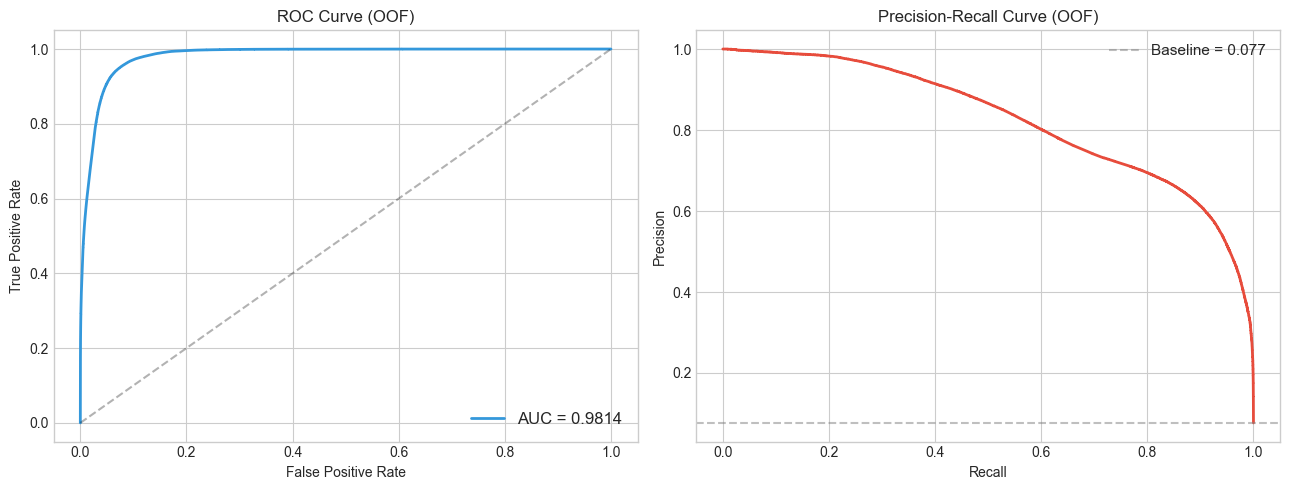

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_train, oof_preds)
axes[0].plot(fpr, tpr, color=COLORS["main"], lw=2, label=f"AUC = {oof_auc:.4f}")
axes[0].plot([0,1],[0,1], "k--", alpha=0.3)
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve (OOF)")
axes[0].legend(fontsize=12)

prec, rec, _ = precision_recall_curve(y_train, oof_preds)
axes[1].plot(rec, prec, color=COLORS["churn"], lw=2)
axes[1].axhline(y_train.mean(), color="gray", linestyle="--", alpha=0.5,
                label=f"Baseline = {y_train.mean():.3f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve (OOF)")
axes[1].legend(fontsize=11)
plt.tight_layout(); plt.show()

### 7.3 · Matrice de confusion

La matrice de confusion montre les quatre résultats possibles lorsqu'on convertit les probabilités prédites en décisions oui/non (seuil de 0.5) :

- **Vrais négatifs** (en haut à gauche) : correctement prédits comme « restés »
- **Faux positifs** (en haut à droite) : prédits « résiliés » mais en réalité restés
- **Faux négatifs** (en bas à gauche) : prédits « restés » mais en réalité résiliés — ce sont les erreurs les plus coûteuses en contexte métier
- **Vrais positifs** (en bas à droite) : correctement prédits comme « résiliés »

Le rapport de classification (precision, recall, F1-score) est affiché en dessous. En contexte métier, on pourrait abaisser le seuil (ex. à 0.3) pour détecter plus de churners, au prix de davantage de fausses alertes.

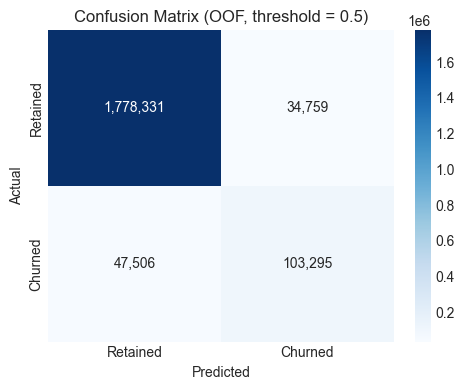

              precision    recall  f1-score   support

    Retained       0.97      0.98      0.98   1813090
     Churned       0.75      0.68      0.72    150801

    accuracy                           0.96   1963891
   macro avg       0.86      0.83      0.85   1963891
weighted avg       0.96      0.96      0.96   1963891



In [32]:
# Threshold 0.5 by default. Lowering it (e.g. to 0.3) catches more churners
# at the cost of more false positives — adjust based on business cost of each error type.
oof_labels = (oof_preds >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_train, oof_labels), annot=True, fmt=",d",
            cmap="Blues", ax=ax,
            xticklabels=["Retained", "Churned"],
            yticklabels=["Retained", "Churned"])
ax.set(xlabel="Predicted", ylabel="Actual",
       title="Confusion Matrix (OOF, threshold = 0.5)")
plt.tight_layout(); plt.show()
print(classification_report(y_train, oof_labels, target_names=["Retained", "Churned"]))

### 7.4 · Importance des features

L'importance des features montre quelles variables le modèle a le plus utilisées pour faire ses prédictions. Le score d'importance ici est le **gain moyen de split** — la réduction moyenne de l'erreur apportée par chaque feature à travers tous les arbres de décision et les 5 folds.

Les features en haut du graphique sont les plus influentes. Cela aide à l'interprétabilité (comprendre *pourquoi* le modèle prédit le churn pour un utilisateur donné) et peut orienter les efforts futurs de feature engineering.

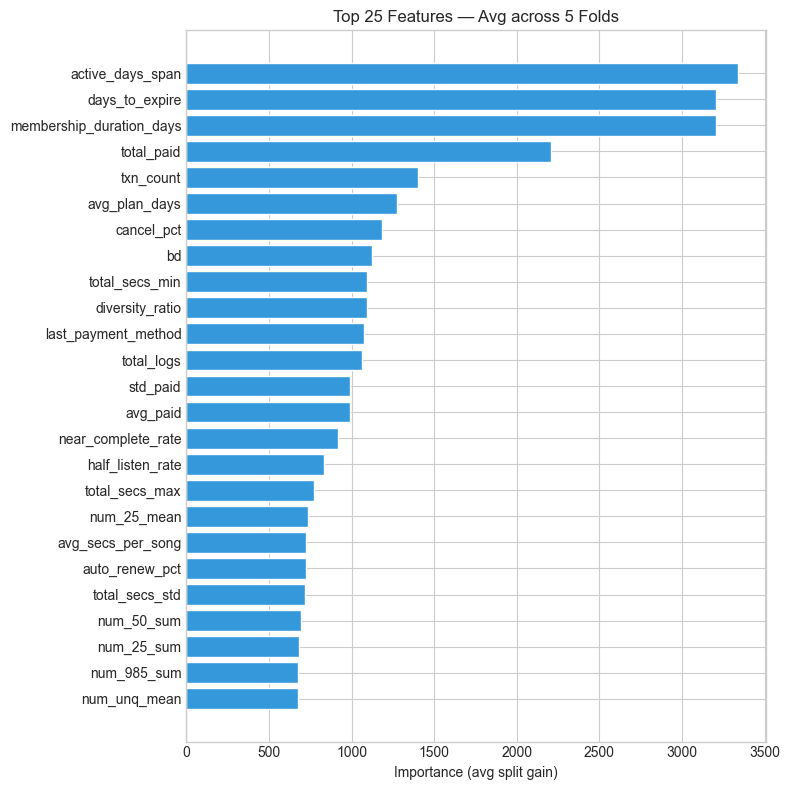

In [25]:
# Averaged across 5 folds to reduce variance from any single split.
imp_df = (pd.DataFrame({"feature": feature_cols, "importance": feat_imp})
          .sort_values("importance", ascending=True))

fig, ax = plt.subplots(figsize=(8, 8))
top25 = imp_df.tail(25)
ax.barh(top25["feature"], top25["importance"], color=COLORS["main"], edgecolor="white")
ax.set(xlabel="Importance (avg split gain)", title="Top 25 Features — Avg across 5 Folds")
plt.tight_layout(); plt.show()

### 7.5 · Distribution des prédictions

Ces histogrammes montrent la *distribution des probabilités de churn prédites* :

- **Gauche (OOF)** — prédictions sur les utilisateurs d'entraînement lorsqu'ils étaient dans le fold de validation. Un modèle performant devrait montrer les churners concentrés vers 1.0 et les retenus vers 0.0, avec une séparation nette entre les deux groupes.

- **Droite (Test)** — prédictions sur le jeu de test de la compétition (pas de labels disponibles). Si cette distribution est très différente de celle OOF, cela peut indiquer un décalage (*distribution shift*) entre les données d'entraînement et de test — un problème fréquent dans les compétitions avec dimension temporelle.

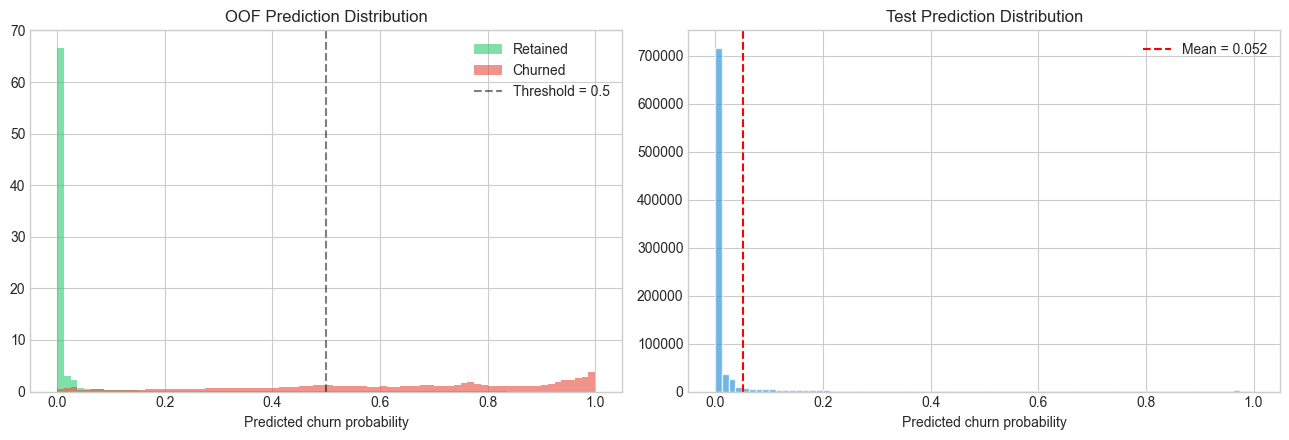

In [26]:
# A well-calibrated model shows clear separation between the two OOF distributions.
# If the test distribution looks very different from OOF, suspect a train/test
# distribution shift — common in time-series competitions like KKBox.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for label, color, lbl in [(0, COLORS["stay"], "Retained"), (1, COLORS["churn"], "Churned")]:
    axes[0].hist(oof_preds[y_train == label], bins=80,
                 alpha=0.6, color=color, density=True, label=lbl)
axes[0].axvline(0.5, color="black", linestyle="--", alpha=0.5, label="Threshold = 0.5")
axes[0].set(title="OOF Prediction Distribution", xlabel="Predicted churn probability")
axes[0].legend()

axes[1].hist(test_preds, bins=80, color=COLORS["main"], alpha=0.7, edgecolor="white")
axes[1].axvline(test_preds.mean(), color="red", linestyle="--",
                label=f"Mean = {test_preds.mean():.3f}")
axes[1].set(title="Test Prediction Distribution", xlabel="Predicted churn probability")
axes[1].legend()
plt.tight_layout(); plt.show()

## 8 · Génération de la soumission

Dernière étape : on lit la liste des identifiants utilisateurs du jeu de test depuis le fichier de soumission exemple, on y attache nos probabilités de churn prédites (moyennées sur les 5 folds), et on écrit le résultat dans un fichier CSV au format attendu par la compétition. L'appel `con.close()` libère la connexion DuckDB et supprime les fichiers temporaires sur disque.

In [27]:
sample_sub_path = PATHS["sample_sub"]

submission = con.execute(
    f"SELECT msno FROM read_parquet('{sample_sub_path}')"
).df()
submission["is_churn"] = test_preds

OUT_PATH = DATA_DIR / "submission_duckdb_v1.csv"
submission.to_csv(OUT_PATH, index=False)

print(f"Saved → {OUT_PATH}")
print(f"Shape:  {submission.shape}")
print("\nPrediction stats:")
print(submission["is_churn"].describe())

con.close()
print("\n✅ DuckDB pipeline complete.")

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\JJAll\\Desktop\\DU DATA (local, Not Drive)\\Machine Learning 2\\Projet\\submission_duckdb_v1.csv'

---
## Résumé

### Points techniques clés de DuckDB

| Technique DuckDB | Rôle dans le pipeline |
|---|---|
| Inférence automatique du schéma depuis les métadonnées Parquet | Pas de définition de schéma manuelle |
| Parallélisme automatique sur tous les cœurs | Pas de tuning de partitions |
| Écriture Parquet + relecture | Cache simple et persistant |
| `QUALIFY ROW_NUMBER() OVER (...)` | Déduplication propre en SQL standard |
| `COALESCE(x, 0.0)` | Remplacement de `NULL` par une valeur par défaut |
| `USING SAMPLE 1 PERCENT` | Échantillonnage intégré en une clause |
| `CREATE VIEW AS SELECT ... CASE WHEN` | Nettoyage déclaratif et lisible |
| `.df()` via le pont Arrow zero-copy | Conversion rapide vers Pandas |
| `NULLIF(x, 0)` | Division sûre sans erreur |

### Prédicteurs clés (classement typique)
1. `last_is_cancel` — annulation explicite, signal le plus fort
2. `last_auto_renew` — risque de churn passif quand désactivé
3. `days_to_expire` — proximité de l'expiration à la dernière transaction
4. `completion_rate` — qualité de l'engagement
5. `membership_duration_days` — signal de fidélité

### Pistes d'amélioration
- **Optuna** — recherche d'hyperparamètres sur `num_leaves`, `learning_rate`, `min_child_samples`
- **Valeurs SHAP** — interprétabilité par utilisateur via `shap.TreeExplainer`
- **Features à décroissance temporelle** — pondérer les logs récents plus fortement (ex. `completion_rate` des 30 derniers jours vs. global)
- **Target encoding** — pour `city` et `registered_via`, à l'intérieur de chaque fold de CV
- **Stacking** — combiner LightGBM avec XGBoost / CatBoost pour un gain d'ensemble